# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [2]:
#!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  7588k      0 --:--:--  0:01:58 --:--:-- 6850k


In [3]:
#!rm SUSY.csv

rm: SUSY.csv: No such file or directory


In [4]:
#!gunzip SUSY.csv.gz

In [6]:
ls -lh

total 4685592
-rw-------@ 1 afarbin  staff   389K Mar 20 13:47 Lab.7.ipynb
-rw-r--r--@ 1 afarbin  staff   8.0M Mar 20 12:18 Lab.7.pdf
-rw-r--r--@ 1 afarbin  staff   2.2G Mar 20 11:36 SUSY.csv


The data is provided as a comma separated file.

In [2]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [7]:
!ls -lh

total 4685592
-rw-------@ 1 afarbin  staff   389K Mar 20 13:47 Lab.7.ipynb
-rw-r--r--@ 1 afarbin  staff   8.0M Mar 20 12:18 Lab.7.pdf
-rw-r--r--@ 1 afarbin  staff   2.2G Mar 20 11:36 SUSY.csv


We see that we have 5 million datapoints.

In [8]:
!wc -l SUSY.csv

 5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [9]:
!head -500000 SUSY.csv > SUSY-small.csv

In [10]:
ls -lh

total 5152448
-rw-------@ 1 afarbin  staff   389K Mar 20 13:49 Lab.7.ipynb
-rw-r--r--@ 1 afarbin  staff   8.0M Mar 20 12:18 Lab.7.pdf
-rw-r--r--  1 afarbin  staff   228M Mar 20 13:50 SUSY-small.csv
-rw-r--r--@ 1 afarbin  staff   2.2G Mar 20 11:36 SUSY.csv


In [11]:
! wc -l SUSY-small.csv

  500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [12]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [13]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [14]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [15]:
FeatureNames

['axial_MET',
 'MT2',
 'M_Delta_R',
 'M_R',
 'S_R',
 'M_TR_2',
 'dPhi_r_b',
 'R',
 'MET_rel',
 'cos_theta_r1']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [17]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/iostream.py", line 105, in _handle_subscription
    event_type = frame[0]
                 ~~~~~^^^
IndexError: index out of range
ERROR:tornado.general:Uncaught exception in zmqstream callback
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 600, in _handle_events
    self._handle_recv()
    ~~~~~~~~~~~~~~~~~^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 629, in _handle_recv
    self._run_callback(callback, msg)
    ~~~~~~~~~~~~~~~~~~^

You can see the data in Jupyter by just evaluateing the dataframe:

In [11]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [11]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


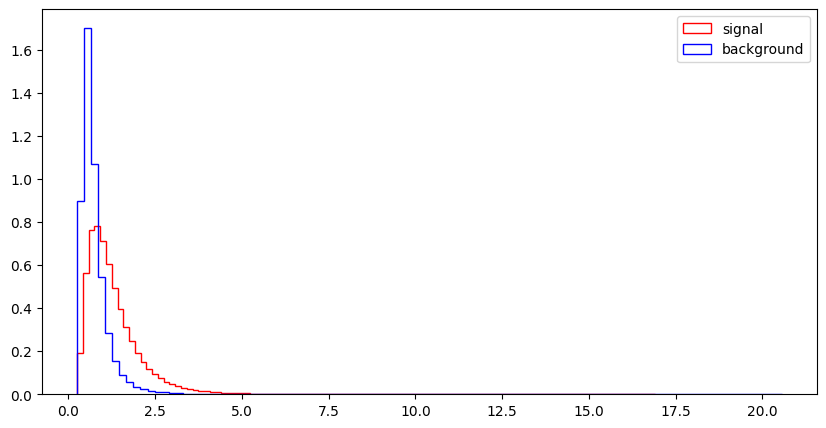

l_1_eta


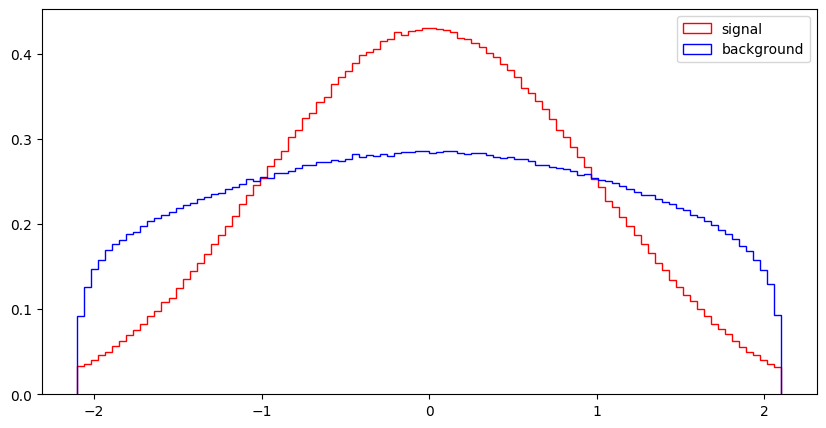

l_1_phi


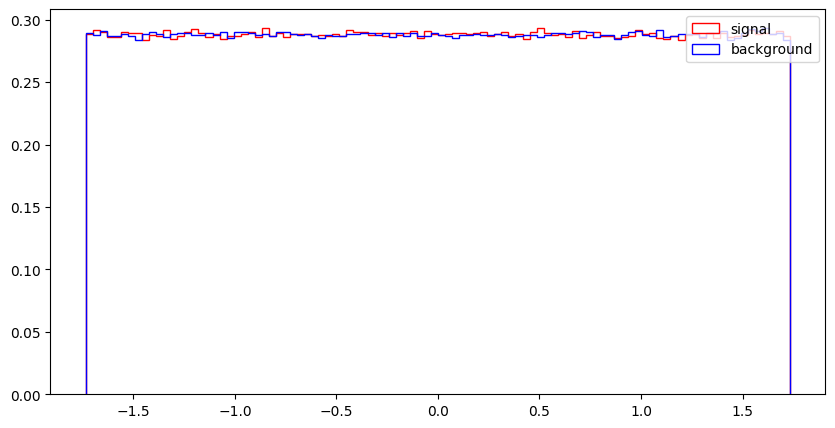

l_2_pT


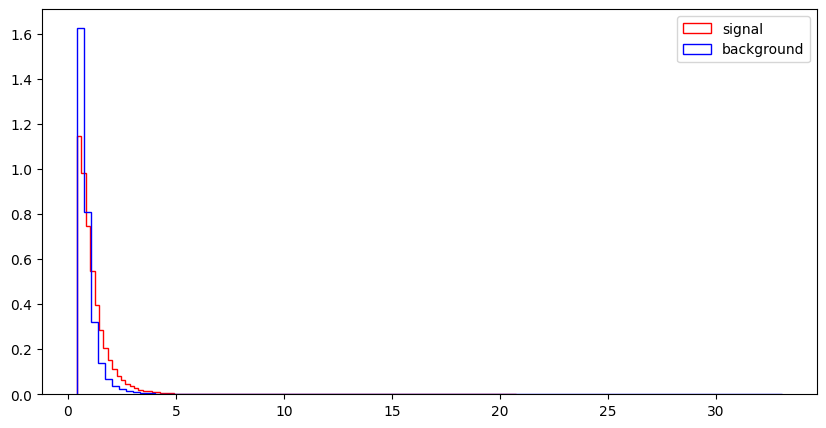

l_2_eta


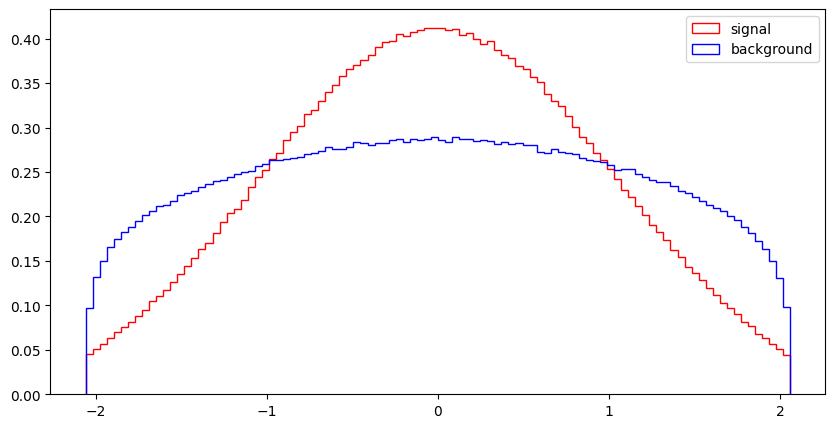

l_2_phi


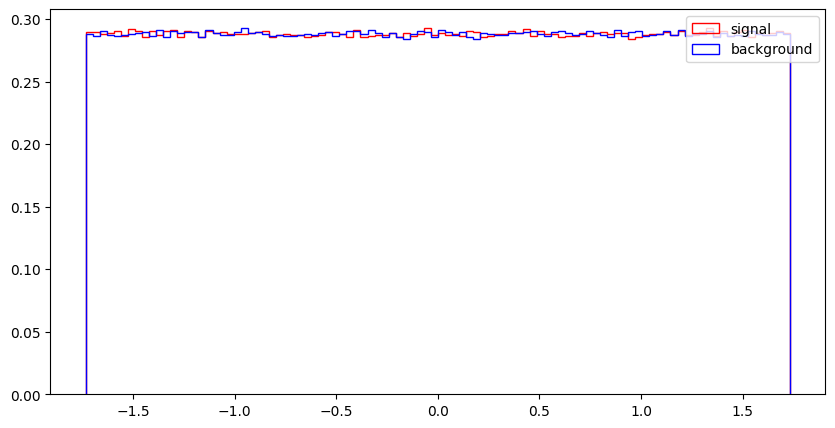

MET


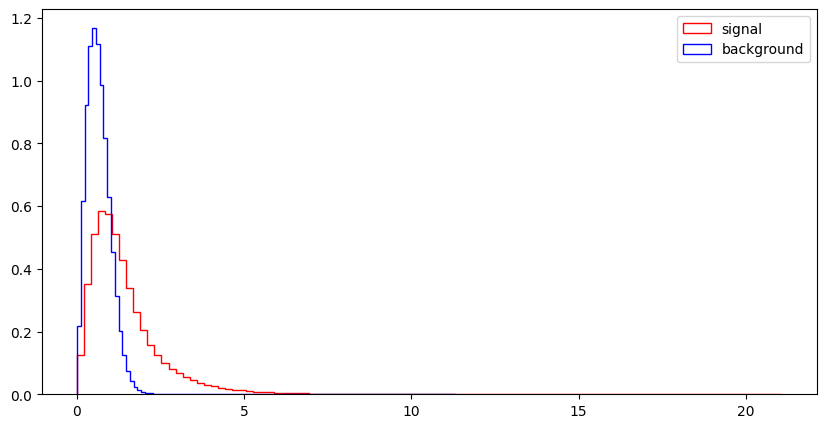

MET_phi


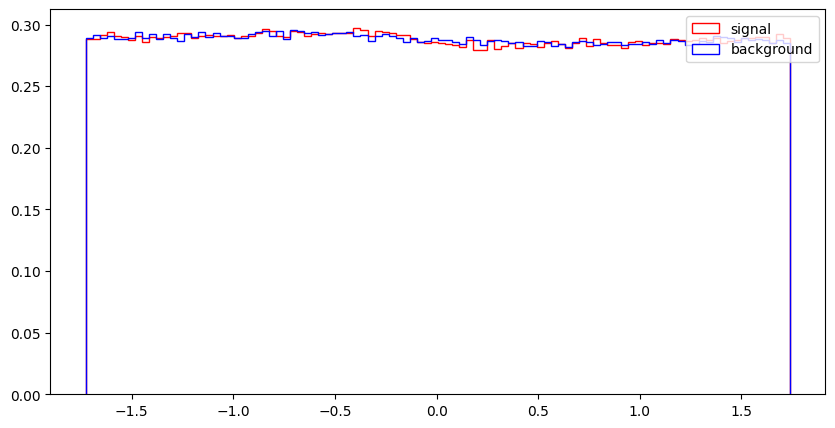

MET_rel


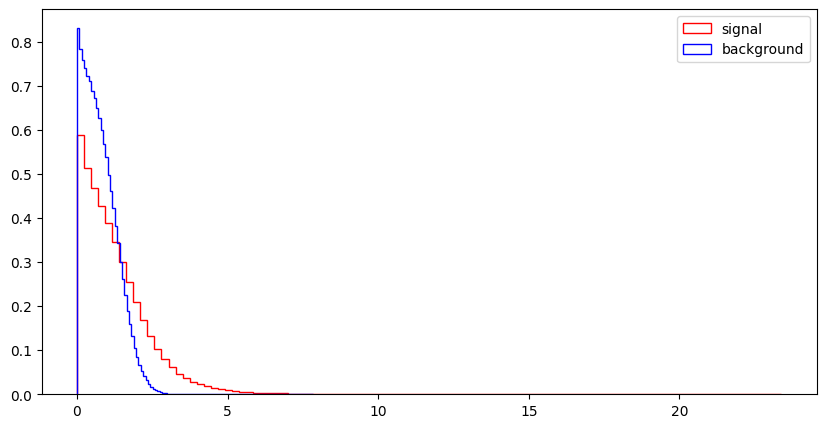

axial_MET


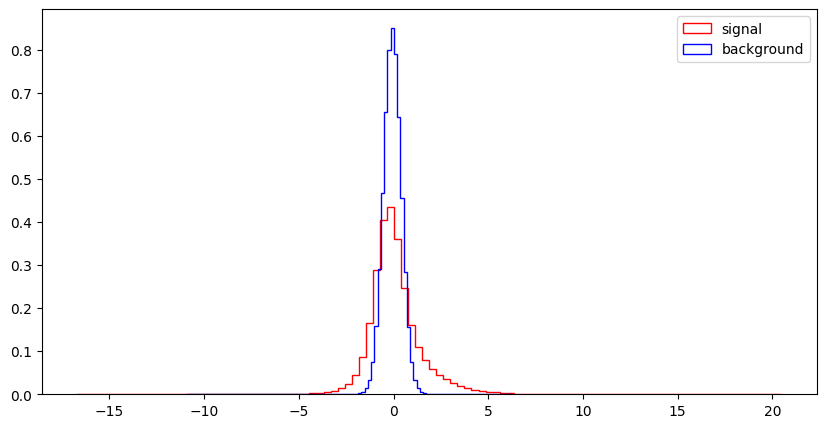

M_R


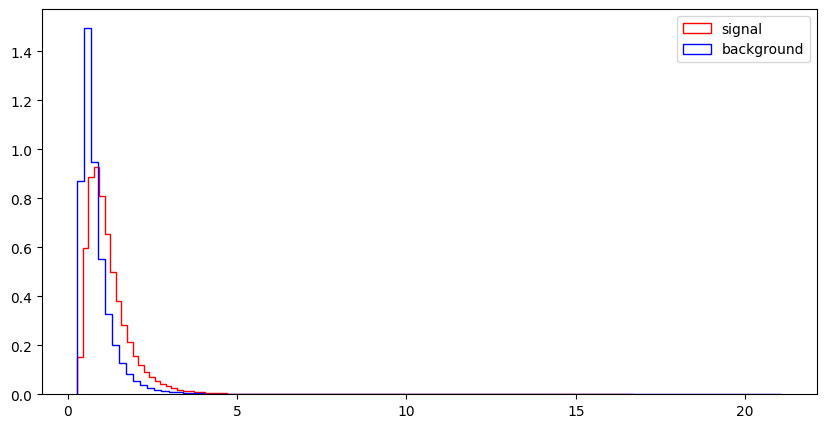

M_TR_2


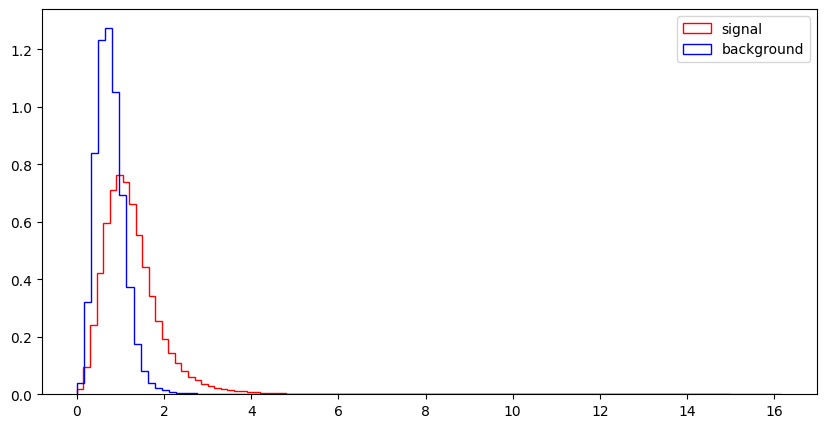

R


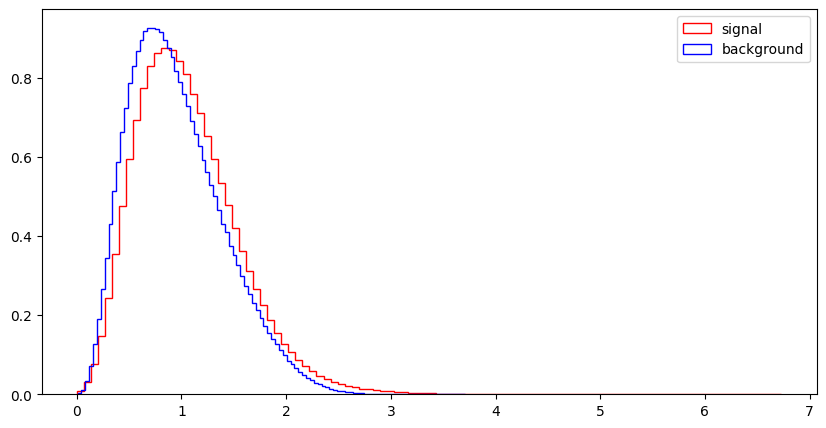

MT2


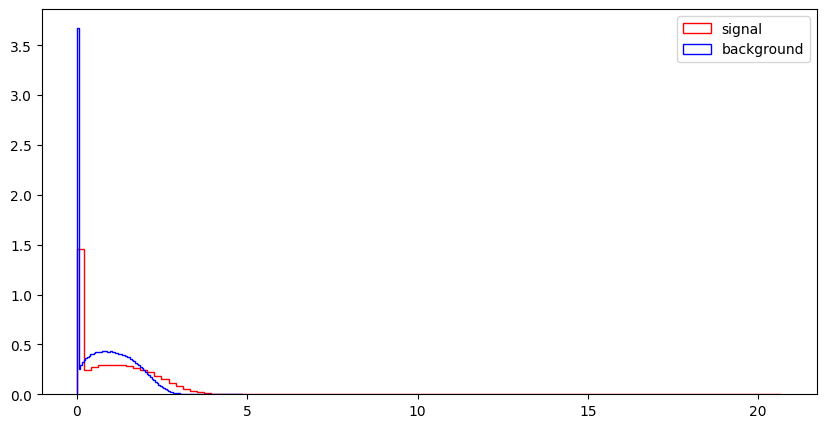

S_R


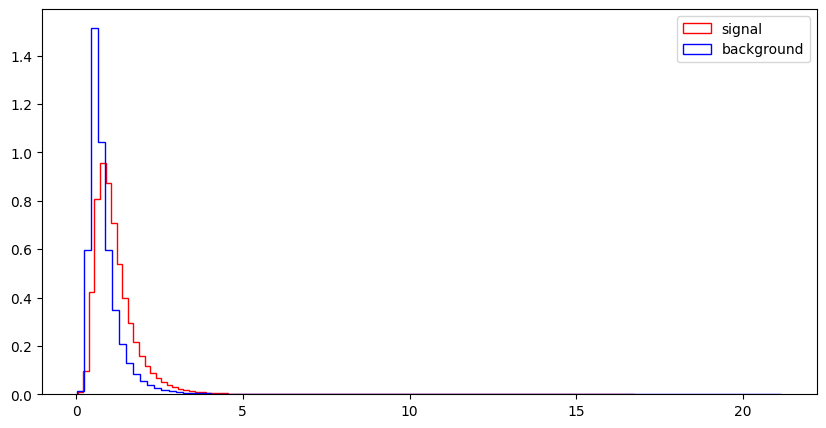

M_Delta_R


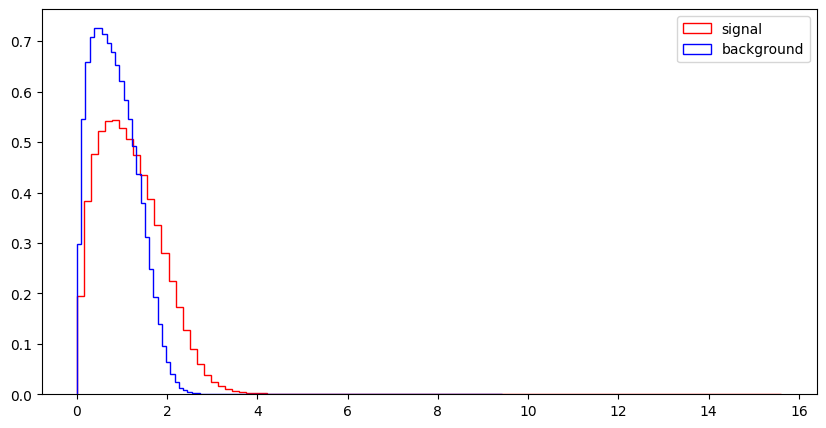

dPhi_r_b


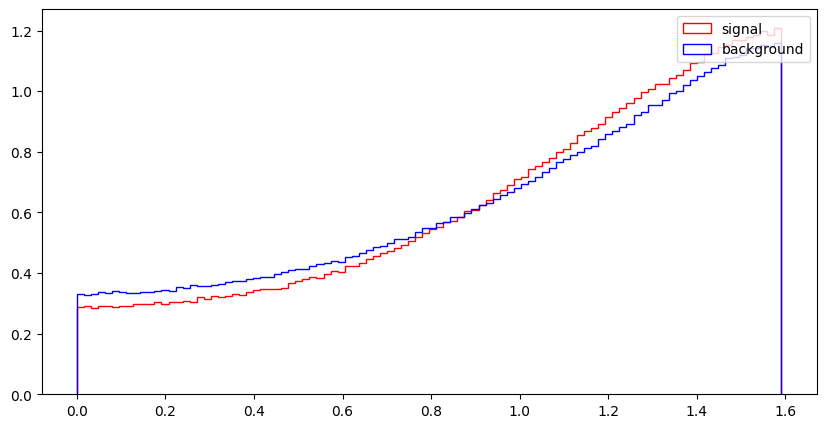

cos_theta_r1


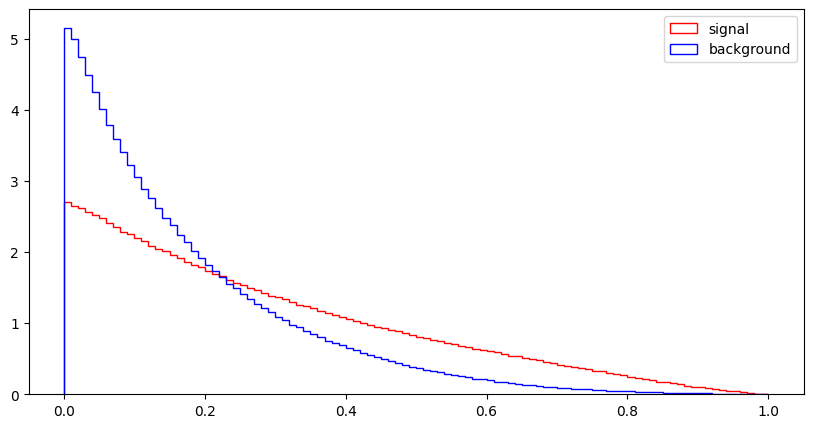

In [13]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

/usr/local/lib/python3.10/dist-packages/matplotlib/axes/_axes.py:7104: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/usr/local/lib/python3.10/dist-packages/matplotlib/axes/_axes.py:7105: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

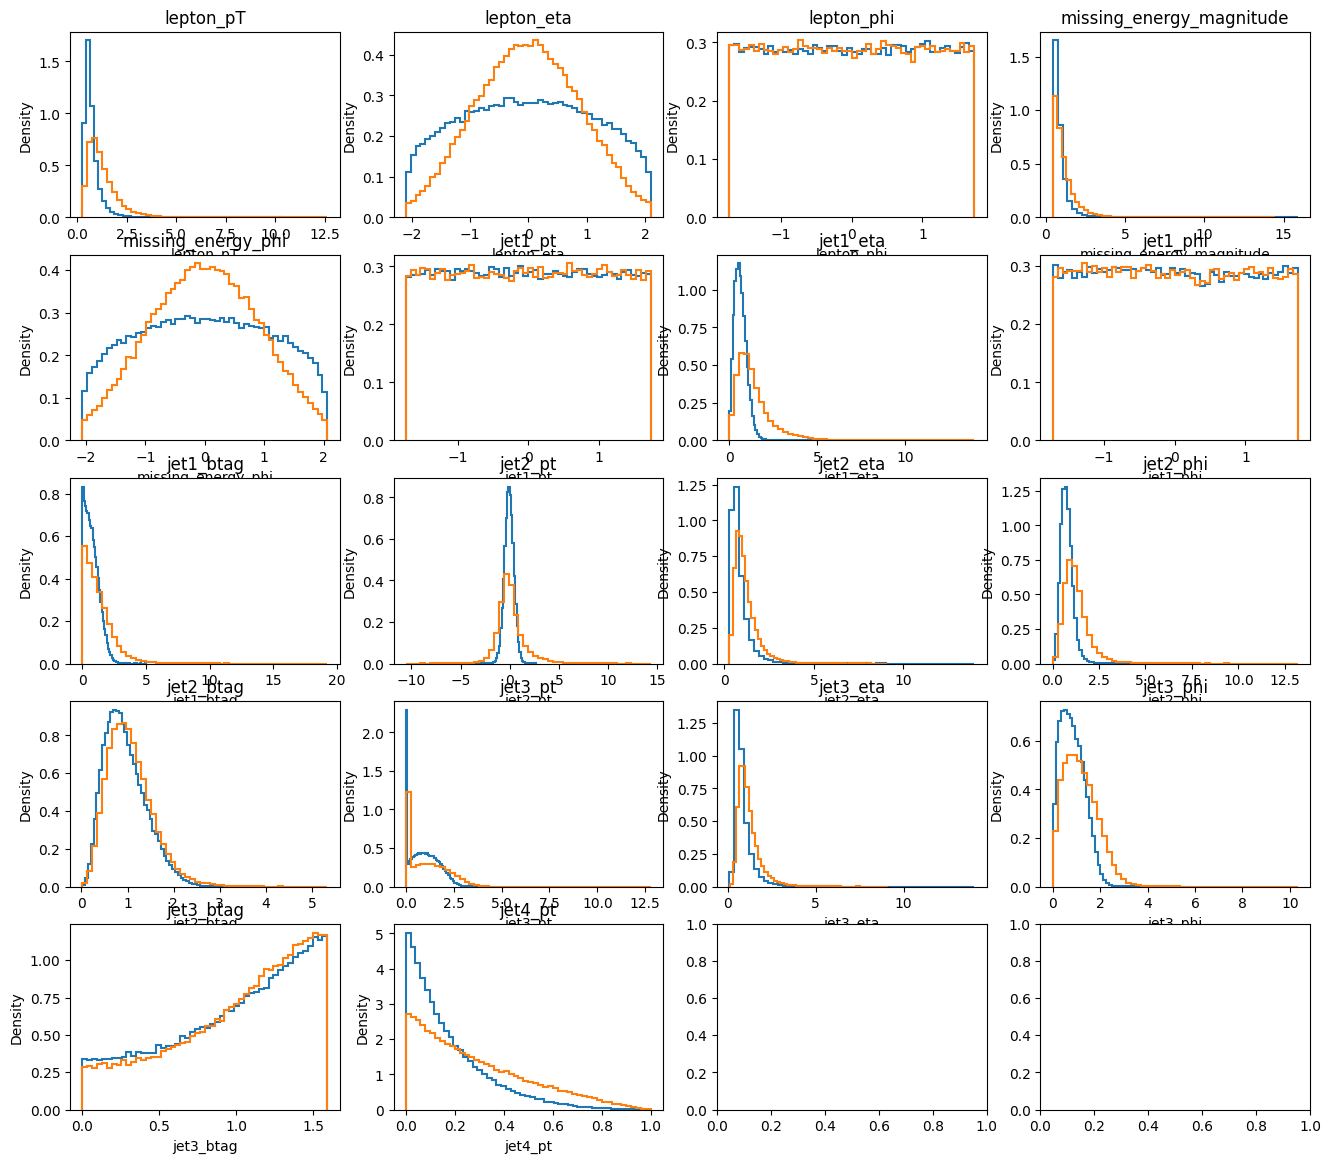

In [5]:
# Install libraries if needed
!pip install pandas matplotlib numpy -q

# Download dataset if it doesn't exist
import os
if not os.path.exists("SUSY.csv"):
    !wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz
    !gunzip SUSY.csv.gz

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Column names from SUSY documentation
VarNames = [
    "isSignal",
    "lepton_pT","lepton_eta","lepton_phi",
    "missing_energy_magnitude","missing_energy_phi",
    "jet1_pt","jet1_eta","jet1_phi","jet1_btag",
    "jet2_pt","jet2_eta","jet2_phi","jet2_btag",
    "jet3_pt","jet3_eta","jet3_phi","jet3_btag",
    "jet4_pt","jet4_eta","jet4_phi","jet4_btag"
]

# Load only part of dataset so it runs faster
df = pd.read_csv("SUSY.csv", names=VarNames, nrows=200000)

# Separate signal and background
signal = df[df["isSignal"] == 1]
background = df[df["isSignal"] == 0]

# Create multi-plot figure
fig, axes = plt.subplots(5,4, figsize=(16,14))
axes = axes.flatten()

for i, var in enumerate(VarNames[1:]):  # skip label column
    axes[i].hist(background[var], bins=50, density=True, histtype='step', linewidth=1.5, label="Background")
    axes[i].hist(signal[var], bins=50, density=True, histtype='step', linewidth=1.5, label="Signal")
    axes[i].set_title(var)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Density")

axes[0].legend()

plt.tight_layout()
plt.show()

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

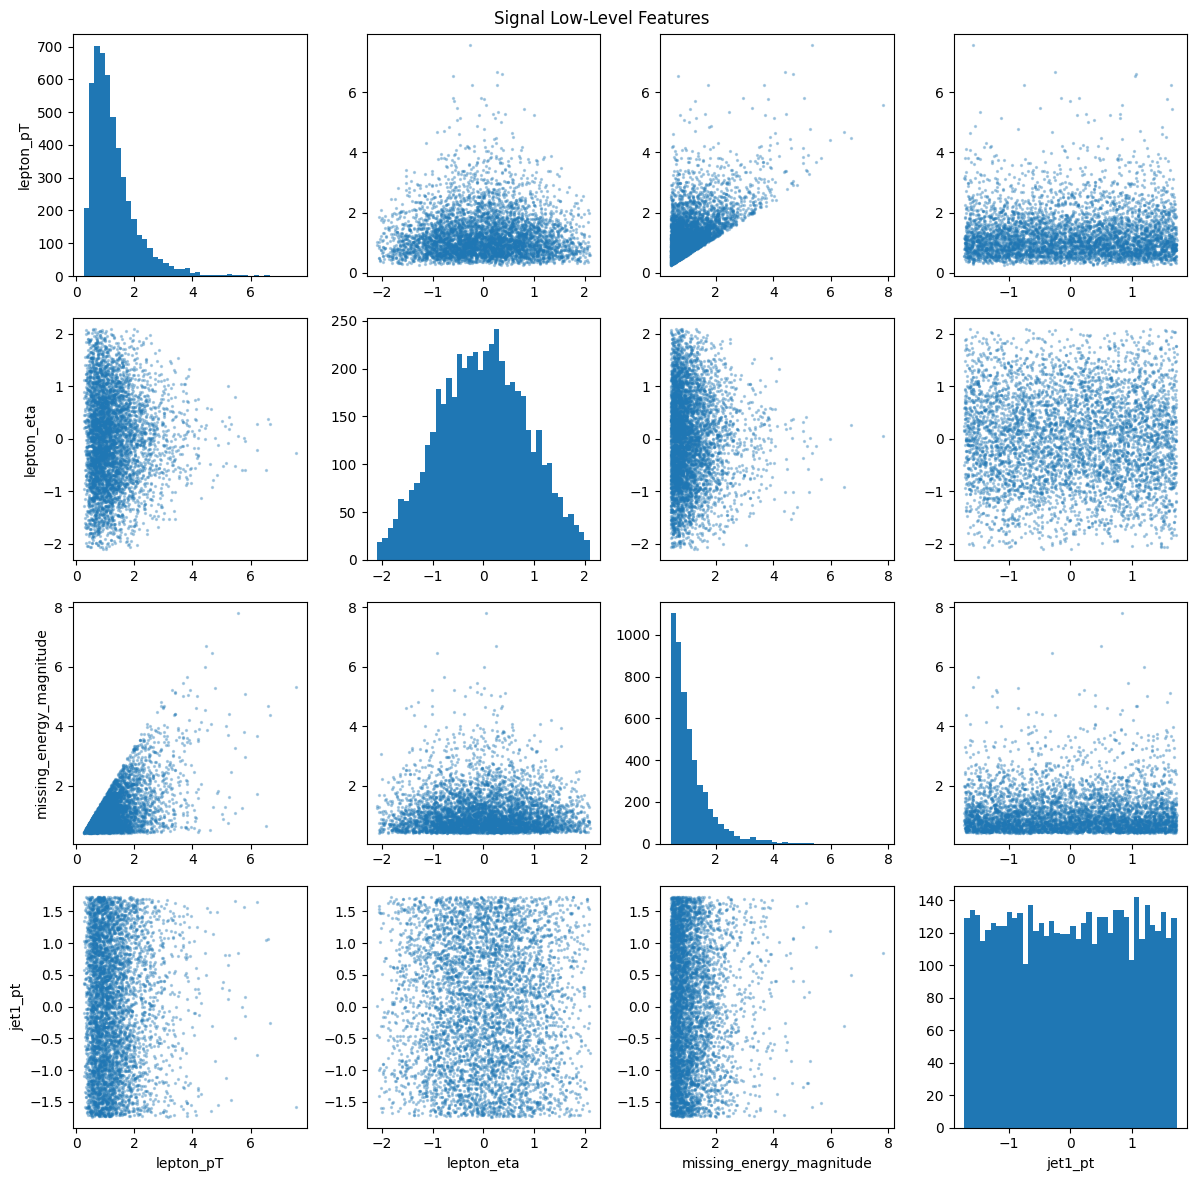

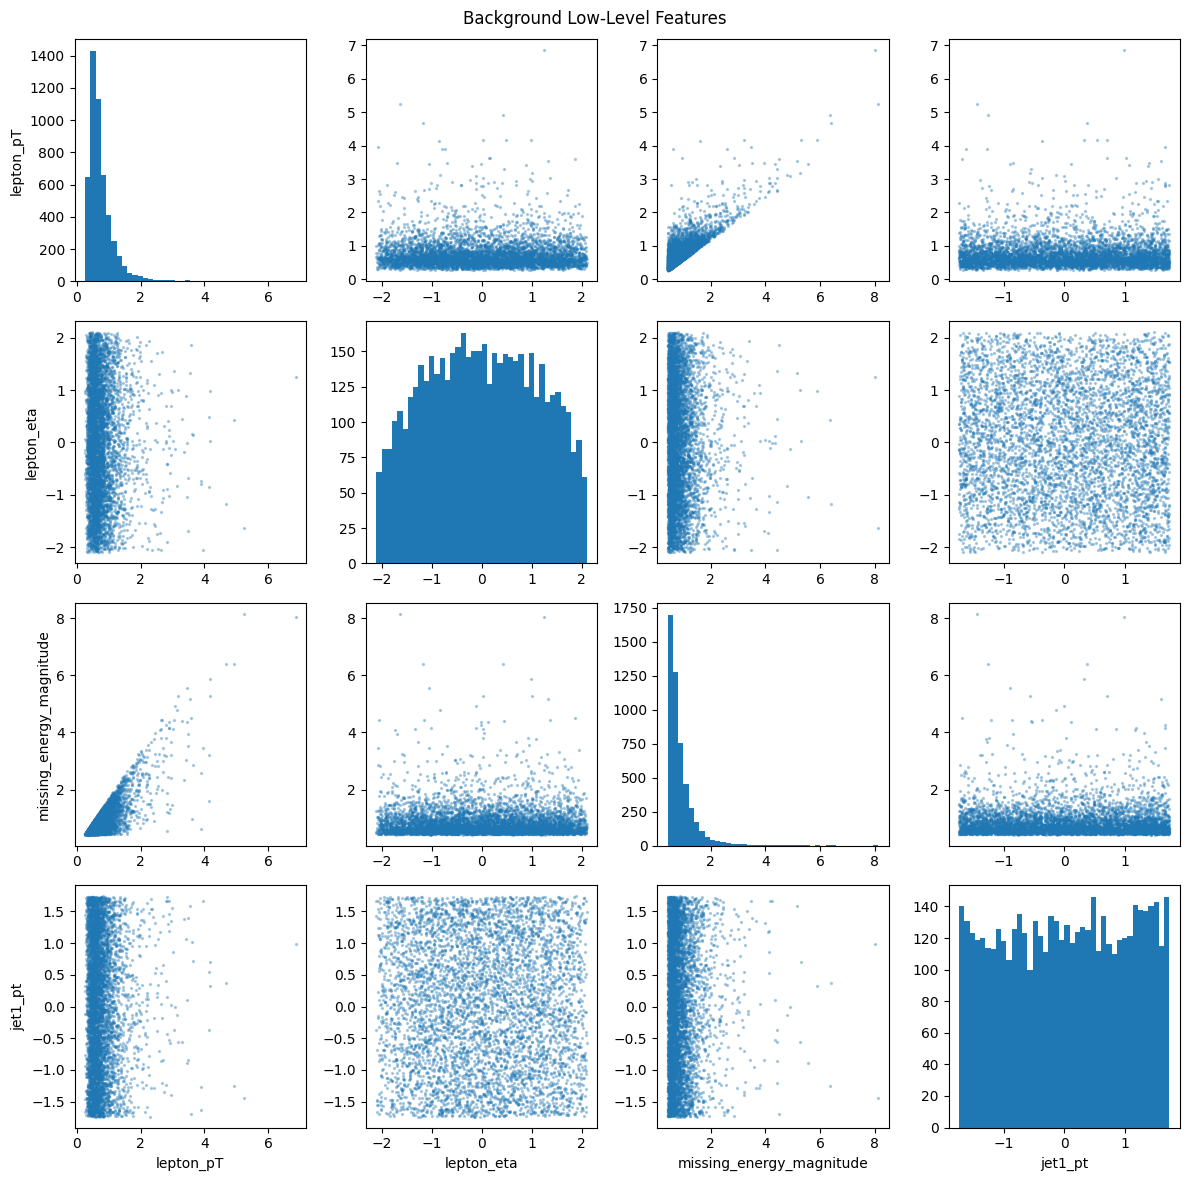

/usr/local/lib/python3.10/dist-packages/matplotlib/axes/_axes.py:7104: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/usr/local/lib/python3.10/dist-packages/matplotlib/axes/_axes.py:7105: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

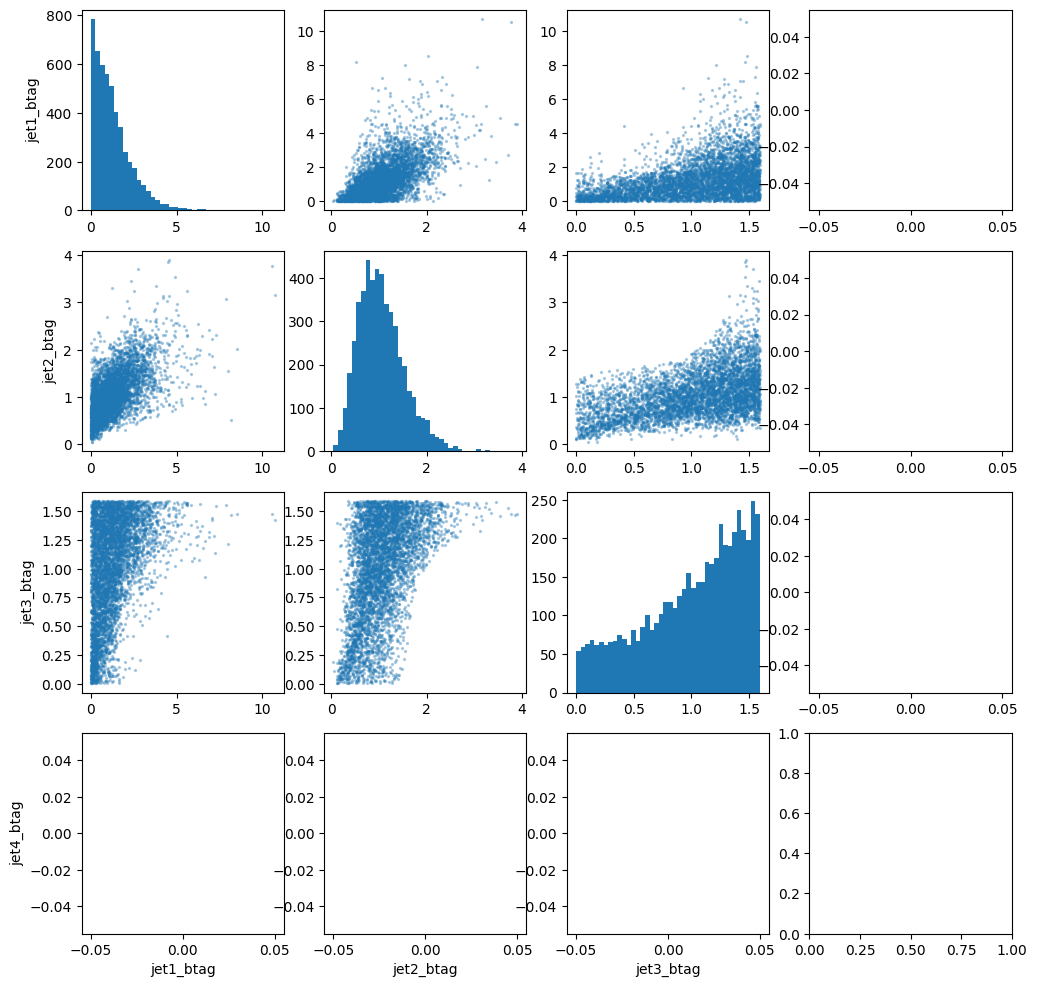

In [6]:
!pip install pandas matplotlib numpy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Variable names
VarNames = [
    "isSignal",
    "lepton_pT","lepton_eta","lepton_phi",
    "missing_energy_magnitude","missing_energy_phi",
    "jet1_pt","jet1_eta","jet1_phi","jet1_btag",
    "jet2_pt","jet2_eta","jet2_phi","jet2_btag",
    "jet3_pt","jet3_eta","jet3_phi","jet3_btag",
    "jet4_pt","jet4_eta","jet4_phi","jet4_btag"
]

# Load part of dataset (full dataset is very large)
df = pd.read_csv("SUSY.csv", names=VarNames, nrows=100000)

# Separate signal and background
signal = df[df["isSignal"] == 1]
background = df[df["isSignal"] == 0]

# Pair plot function (with sampling to speed it up)
def pair_plot(data, variables, title):

    data = data.sample(5000)  # speed improvement

    n = len(variables)
    fig, axes = plt.subplots(n, n, figsize=(12,12))

    for i in range(n):
        for j in range(n):

            if i == j:
                axes[i,j].hist(data[variables[i]], bins=40)
            else:
                axes[i,j].scatter(data[variables[j]], data[variables[i]], s=2, alpha=0.3)

            if i == n-1:
                axes[i,j].set_xlabel(variables[j])
            if j == 0:
                axes[i,j].set_ylabel(variables[i])

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Low-level features
low_features = [
    "lepton_pT",
    "lepton_eta",
    "missing_energy_magnitude",
    "jet1_pt"
]

# High-level features
high_features = [
    "jet1_btag",
    "jet2_btag",
    "jet3_btag",
    "jet4_btag"
]

# Generate plots
pair_plot(signal, low_features, "Signal Low-Level Features")
pair_plot(background, low_features, "Background Low-Level Features")

pair_plot(signal, high_features, "Signal High-Level Features")
pair_plot(background, high_features, "Background High-Level Features")

# Part C answer
print("Observables that appear most useful for separating signal and background:")
print("missing_energy_magnitude, lepton_pT, jet1_pt, and the jet b-tag variables.")

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

Hint: Example code for embedding a `tabulate` table into a notebook:

In [15]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


In [7]:
# Install tabulate if needed
!pip install tabulate -q

import pandas as pd
import numpy as np
from tabulate import tabulate
from IPython.display import HTML, display

# Variable names
VarNames = [
    "isSignal",
    "lepton_pT","lepton_eta","lepton_phi",
    "missing_energy_magnitude","missing_energy_phi",
    "jet1_pt","jet1_eta","jet1_phi","jet1_btag",
    "jet2_pt","jet2_eta","jet2_phi","jet2_btag",
    "jet3_pt","jet3_eta","jet3_phi","jet3_btag",
    "jet4_pt","jet4_eta","jet4_phi","jet4_btag"
]

# Load a subset of the dataset
df = pd.read_csv("SUSY.csv", names=VarNames, nrows=50000)

# Feature groups
low_features = [
    "lepton_pT","lepton_eta","lepton_phi",
    "missing_energy_magnitude","missing_energy_phi",
    "jet1_pt","jet1_eta","jet1_phi",
    "jet2_pt","jet2_eta","jet2_phi",
    "jet3_pt","jet3_eta","jet3_phi",
    "jet4_pt","jet4_eta","jet4_phi"
]

high_features = [
    "jet1_btag","jet2_btag","jet3_btag","jet4_btag"
]

# Function for covariance + correlation tables
def make_tables(data, features, title):

    X = data[features].to_numpy()

    cov_matrix = np.cov(X, rowvar=False)
    corr_matrix = np.corrcoef(X, rowvar=False)

    # Round values for nicer formatting
    cov_table = np.round(cov_matrix,3)
    corr_table = np.round(corr_matrix,3)

    print(title + " Covariance Matrix")
    display(HTML(tabulate(cov_table, headers=features, tablefmt="html")))

    print(title + " Correlation Matrix")
    display(HTML(tabulate(corr_table, headers=features, tablefmt="html")))

# Generate tables
make_tables(df, VarNames[1:], "All Observables")
make_tables(df, low_features, "Low-Level Features")
make_tables(df, high_features, "High-Level Features")

All Observables Covariance Matrix


lepton_pT,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet1_pt,jet1_eta,jet1_phi,jet1_btag,jet2_pt,jet2_eta,jet2_phi,jet2_btag,jet3_pt,jet3_eta,jet3_phi,jet3_btag,jet4_pt,jet4_eta,jet4_phi,jet4_btag
0.473,-0.001,0,0.305,0.001,-0.001,0.238,-0.002,0.106,-0.016,0.369,0.294,-0.058,-0.011,0.348,0.104,-0.046,0.023,nan,nan,nan
-0.001,1.008,-0.012,-0.001,0.407,0.001,-0.008,-0.005,-0.004,-0.01,-0.001,-0.001,-0,0.002,-0.001,-0.001,-0.002,-0,nan,nan,nan
0,-0.012,1.006,0.004,-0.009,-0.265,-0.001,-0.188,-0.001,-0,0.004,0,-0.003,0,0.004,-0.001,0.003,-0,nan,nan,nan
0.305,-0.001,0.004,0.427,-0,-0.003,0.083,-0.004,0.006,0.048,0.328,0.166,-0.098,-0.066,0.325,0.011,-0.002,-0.028,nan,nan,nan
0.001,0.407,-0.009,-0,1.007,-0.004,-0.002,-0.003,0.004,-0.01,0.002,0.002,0,0.007,0.002,0.003,-0.001,0.001,nan,nan,nan
-0.001,0.001,-0.265,-0.003,-0.004,1.005,0,-0.032,-0.001,0.003,-0.003,-0,0.001,-0,-0.004,-0.001,-0.002,0.001,nan,nan,nan
0.238,-0.008,-0.001,0.083,-0.002,0,0.771,0,0.548,0.153,0.151,0.371,0.184,0.157,0.171,0.315,0.145,0.073,nan,nan,nan
-0.002,-0.005,-0.188,-0.004,-0.003,-0.032,0,1.003,-0.003,-0.001,-0.004,-0.001,0.003,0.005,-0.005,0.001,-0.002,0.001,nan,nan,nan
0.106,-0.004,-0.001,0.006,0.004,-0.001,0.548,-0.003,0.782,-0.114,0.052,0.305,0.243,0.407,0.089,0.41,0.146,0.055,nan,nan,nan
-0.016,-0.01,-0,0.048,-0.01,0.003,0.153,-0.001,-0.114,1.023,0.012,-0.196,-0.184,-0.459,-0.049,-0.234,-0.027,-0.055,nan,nan,nan


All Observables Correlation Matrix


lepton_pT,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet1_pt,jet1_eta,jet1_phi,jet1_btag,jet2_pt,jet2_eta,jet2_phi,jet2_btag,jet3_pt,jet3_eta,jet3_phi,jet3_btag,jet4_pt,jet4_eta,jet4_phi,jet4_btag
1,-0.001,0,0.68,0.002,-0.001,0.394,-0.002,0.174,-0.022,0.851,0.728,-0.18,-0.018,0.81,0.243,-0.152,0.171,nan,nan,nan
-0.001,1,-0.012,-0.001,0.404,0.001,-0.009,-0.005,-0.004,-0.01,-0.002,-0.003,-0,0.002,-0.001,-0.002,-0.005,-0.001,nan,nan,nan
0,-0.012,1,0.007,-0.009,-0.264,-0.002,-0.187,-0.001,-0,0.006,0,-0.005,0,0.006,-0.002,0.006,-0.002,nan,nan,nan
0.68,-0.001,0.007,1,-0,-0.005,0.145,-0.006,0.01,0.073,0.796,0.432,-0.321,-0.119,0.798,0.026,-0.008,-0.215,nan,nan,nan
0.002,0.404,-0.009,-0,1,-0.004,-0.002,-0.003,0.004,-0.01,0.003,0.003,0.001,0.008,0.003,0.005,-0.003,0.003,nan,nan,nan
-0.001,0.001,-0.264,-0.005,-0.004,1,0,-0.032,-0.001,0.003,-0.005,-0.001,0.001,-0,-0.006,-0.002,-0.005,0.004,nan,nan,nan
0.394,-0.009,-0.002,0.145,-0.002,0,1,0,0.706,0.173,0.273,0.719,0.447,0.208,0.313,0.577,0.38,0.421,nan,nan,nan
-0.002,-0.005,-0.187,-0.006,-0.003,-0.032,0,1,-0.004,-0.001,-0.007,-0.001,0.007,0.006,-0.008,0.001,-0.004,0.007,nan,nan,nan
0.174,-0.004,-0.001,0.01,0.004,-0.001,0.706,-0.004,1,-0.127,0.093,0.586,0.586,0.536,0.161,0.745,0.38,0.313,nan,nan,nan
-0.022,-0.01,-0,0.073,-0.01,0.003,0.173,-0.001,-0.127,1,0.019,-0.33,-0.388,-0.53,-0.078,-0.371,-0.062,-0.274,nan,nan,nan


Low-Level Features Covariance Matrix


...

lepton_pT,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet1_pt,jet1_eta,jet1_phi,jet2_pt,jet2_eta,jet2_phi,jet3_pt,jet3_eta,jet3_phi,jet4_pt,jet4_eta,jet4_phi
1,-0.001,0,0.68,0.002,-0.001,0.394,-0.002,-0.022,0.851,0.728,-0.018,0.81,0.243,0.171,nan,nan
-0.001,1,-0.012,-0.001,0.404,0.001,-0.009,-0.005,-0.01,-0.002,-0.003,0.002,-0.001,-0.002,-0.001,nan,nan
0,-0.012,1,0.007,-0.009,-0.264,-0.002,-0.187,-0,0.006,0,0,0.006,-0.002,-0.002,nan,nan
0.68,-0.001,0.007,1,-0,-0.005,0.145,-0.006,0.073,0.796,0.432,-0.119,0.798,0.026,-0.215,nan,nan
0.002,0.404,-0.009,-0,1,-0.004,-0.002,-0.003,-0.01,0.003,0.003,0.008,0.003,0.005,0.003,nan,nan
-0.001,0.001,-0.264,-0.005,-0.004,1,0,-0.032,0.003,-0.005,-0.001,-0,-0.006,-0.002,0.004,nan,nan
0.394,-0.009,-0.002,0.145,-0.002,0,1,0,0.173,0.273,0.719,0.208,0.313,0.577,0.421,nan,nan
-0.002,-0.005,-0.187,-0.006,-0.003,-0.032,0,1,-0.001,-0.007,-0.001,0.006,-0.008,0.001,0.007,nan,nan
-0.022,-0.01,-0,0.073,-0.01,0.003,0.173,-0.001,1,0.019,-0.33,-0.53,-0.078,-0.371,-0.274,nan,nan
0.851,-0.002,0.006,0.796,0.003,-0.005,0.273,-0.007,0.019,1,0.582,-0.063,0.981,0.205,-0.111,nan,nan


High-Level Features Covariance Matrix


jet1_btag,jet2_btag,jet3_btag,jet4_btag
0.782,0.243,0.146,nan
0.243,0.219,0.086,nan
0.146,0.086,0.19,nan
nan,nan,nan,nan


High-Level Features Correlation Matrix


jet1_btag,jet2_btag,jet3_btag,jet4_btag
1,0.586,0.38,nan
0.586,1,0.42,nan
0.38,0.42,1,nan
nan,nan,nan,nan


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

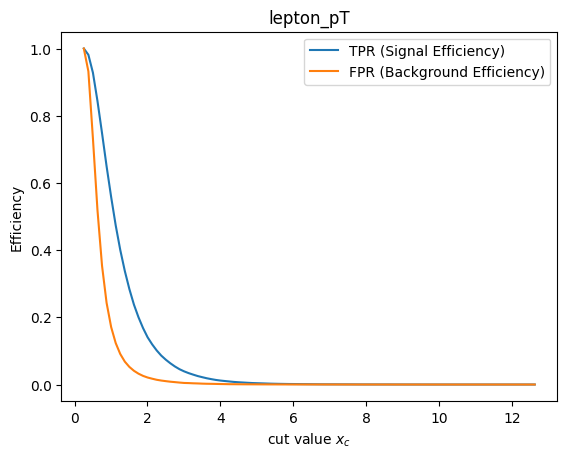

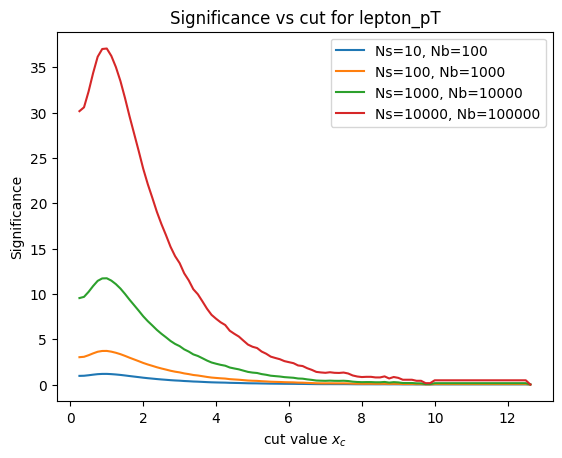

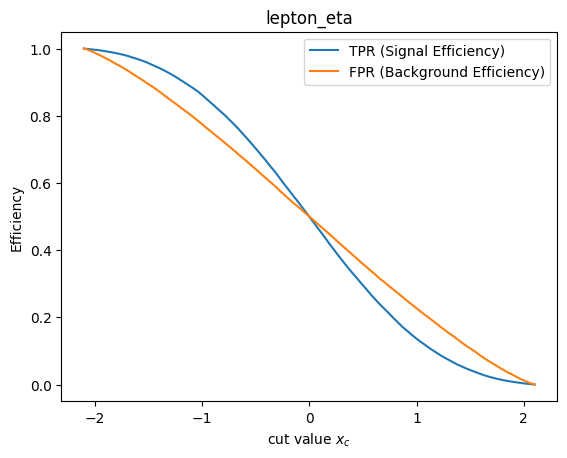

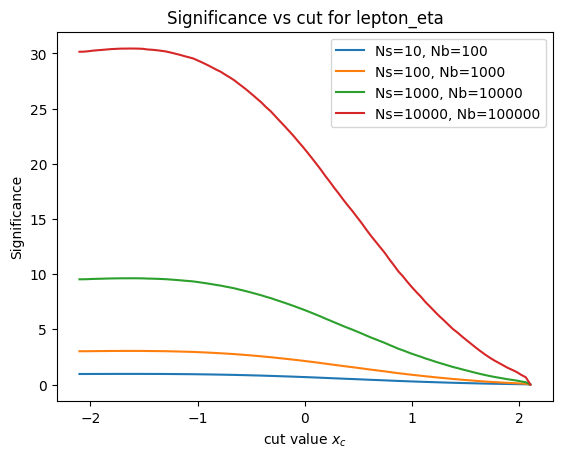

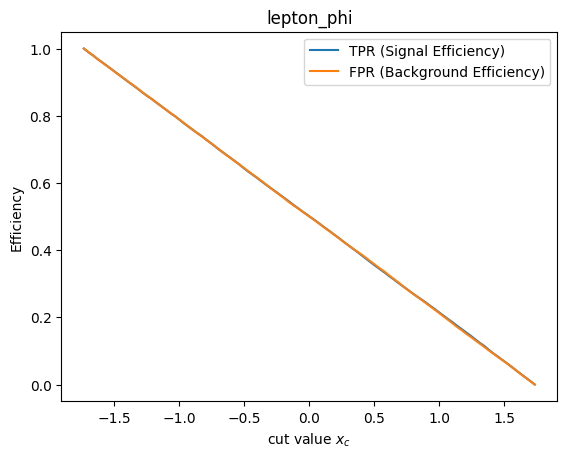

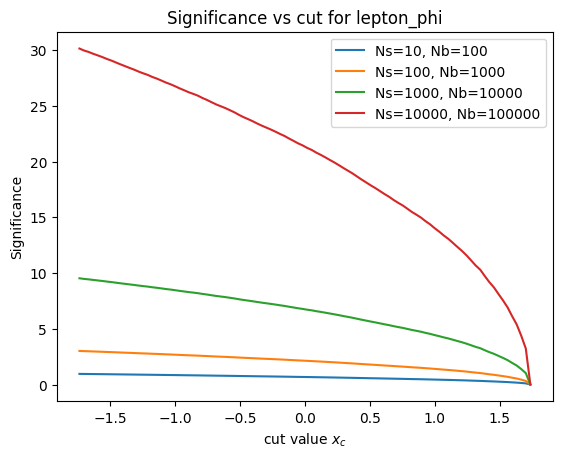

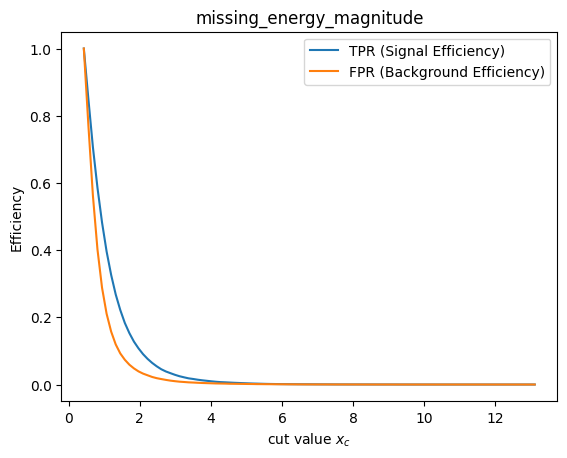

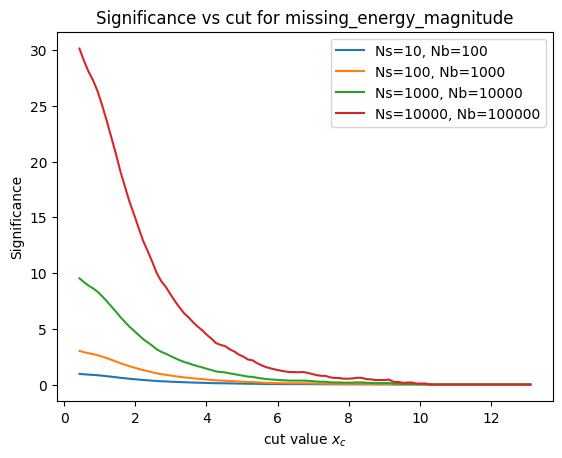

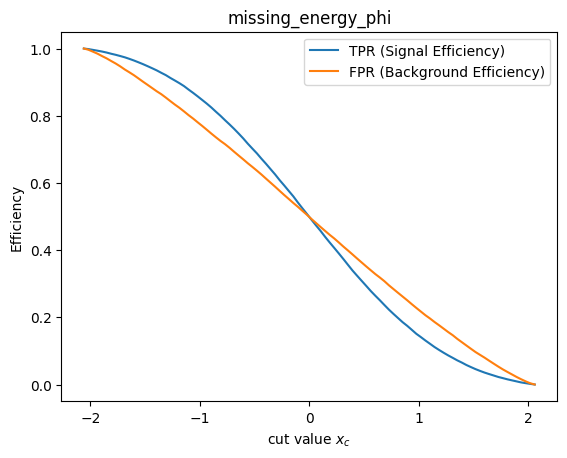

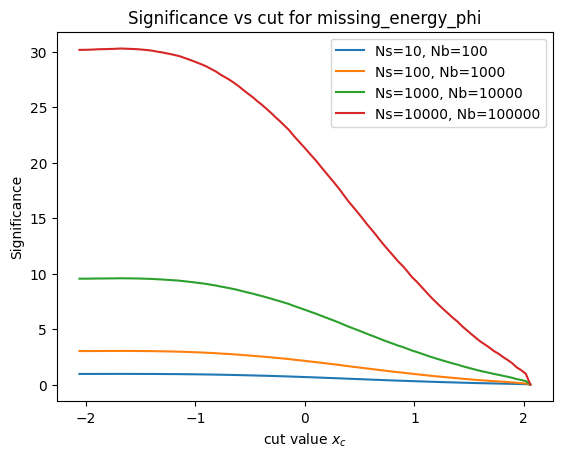

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Variable names
VarNames = [
    "isSignal",
    "lepton_pT","lepton_eta","lepton_phi",
    "missing_energy_magnitude","missing_energy_phi",
    "jet1_pt","jet1_eta","jet1_phi","jet1_btag",
    "jet2_pt","jet2_eta","jet2_phi","jet2_btag",
    "jet3_pt","jet3_eta","jet3_phi","jet3_btag",
    "jet4_pt","jet4_eta","jet4_phi","jet4_btag"
]

# Load subset (full dataset is huge)
df = pd.read_csv("SUSY.csv", names=VarNames, nrows=100000)

signal = df[df["isSignal"] == 1]
background = df[df["isSignal"] == 0]

observables = VarNames[1:6]  # using a few variables to keep plots manageable

# function to compute efficiencies
def efficiencies(sig, bkg, x_c):

    tpr = np.sum(sig > x_c) / len(sig)
    fpr = np.sum(bkg > x_c) / len(bkg)

    return tpr, fpr


for obs in observables:

    sig = signal[obs].values
    bkg = background[obs].values

    x_vals = np.linspace(min(df[obs]), max(df[obs]), 100)

    TPR = []
    FPR = []

    for x in x_vals:
        tpr, fpr = efficiencies(sig, bkg, x)
        TPR.append(tpr)
        FPR.append(fpr)

    # Plot TPR and FPR
    plt.figure()
    plt.plot(x_vals, TPR, label="TPR (Signal Efficiency)")
    plt.plot(x_vals, FPR, label="FPR (Background Efficiency)")
    plt.xlabel("cut value $x_c$")
    plt.ylabel("Efficiency")
    plt.title(obs)
    plt.legend()
    plt.show()

    # Significance scenarios
    scenarios = [
        (10,100),
        (100,1000),
        (1000,10000),
        (10000,100000)
    ]

    plt.figure()

    for Ns, Nb in scenarios:

        sig_vals = []

        for tpr,fpr in zip(TPR,FPR):

            Ns_p = tpr * Ns
            Nb_p = fpr * Nb

            if Ns_p + Nb_p > 0:
                sig_val = Ns_p / np.sqrt(Ns_p + Nb_p)
            else:
                sig_val = 0

            sig_vals.append(sig_val)

        plt.plot(x_vals, sig_vals, label=f"Ns={Ns}, Nb={Nb}")

    plt.xlabel("cut value $x_c$")
    plt.ylabel("Significance")
    plt.title("Significance vs cut for " + obs)
    plt.legend()
    plt.show()

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [ ]:
# Install tabulate if needed
!pip install tabulate -q

import pandas as pd
import numpy as np
from tabulate import tabulate
from IPython.display import display, HTML

# Variable names
VarNames = [
    "isSignal",
    "lepton_pT","lepton_eta","lepton_phi",
    "missing_energy_magnitude","missing_energy_phi",
    "jet1_pt","jet1_eta","jet1_phi","jet1_btag",
    "jet2_pt","jet2_eta","jet2_phi","jet2_btag",
    "jet3_pt","jet3_eta","jet3_phi","jet3_btag",
    "jet4_pt","jet4_eta","jet4_phi","jet4_btag"
]

# Load subset of SUSY dataset
df = pd.read_csv("SUSY.csv", names=VarNames, nrows=100000)

signal = df[df["isSignal"] == 1]
background = df[df["isSignal"] == 0]

# Choose observables (Exercise 6.1)
cuts = [
    ("missing_energy_magnitude", ">", 50),
    ("lepton_pT", ">", 40),
    ("jet1_pt", ">", 60)
]

# Scenarios from Exercise 5.3
scenarios = [
    (10,100),
    (100,1000),
    (1000,10000),
    (10000,100000)
]

# Function to apply a cut
def apply_cut(data, var, op, val):
    if op == ">":
        return data[data[var] > val]
    if op == "<":
        return data[data[var] < val]
    return data

# Build cut flow table
for Ns,Nb in scenarios:

    sig_data = signal.copy()
    bkg_data = background.copy()

    table = []

    for var,op,val in cuts:

        sig_data = apply_cut(sig_data,var,op,val)
        bkg_data = apply_cut(bkg_data,var,op,val)

        eps_s = len(sig_data)/len(signal)
        eps_b = len(bkg_data)/len(background)

        Ns_p = eps_s * Ns
        Nb_p = eps_b * Nb

        if Ns_p + Nb_p > 0:
            significance = Ns_p / np.sqrt(Ns_p + Nb_p)
        else:
            significance = 0

        table.append([
            f"{var} {op} {val}",
            round(eps_s,3),
            round(eps_b,3),
            round(Ns_p,2),
            round(Nb_p,2),
            round(significance,3)
        ])

    print(f"\nScenario Ns={Ns}, Nb={Nb}\n")

    display(HTML(tabulate(
        table,
        headers=["Cut","ε_s","ε_b","N_s'","N_b'","Significance"],
        tablefmt="html"
    )))

In [ ]:
#If observables are correlated, applying cuts independently can lead to suboptimal results. For example, jet momentum variables are often correlated. Optimizing one variable without accounting for another may remove useful signal events.

#Changing the order of selections can slightly change the final efficiencies and significance because the optimization assumes the previous cuts have already modified the distributions.

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Variable names
VarNames = [
    "isSignal",
    "lepton_pT","lepton_eta","lepton_phi",
    "missing_energy_magnitude","missing_energy_phi",
    "jet1_pt","jet1_eta","jet1_phi","jet1_btag",
    "jet2_pt","jet2_eta","jet2_phi","jet2_btag",
    "jet3_pt","jet3_eta","jet3_phi","jet3_btag",
    "jet4_pt","jet4_eta","jet4_phi","jet4_btag"
]

# Load subset
df = pd.read_csv("SUSY.csv", names=VarNames, nrows=100000)

signal = df[df["isSignal"] == 1]
background = df[df["isSignal"] == 0]

# Function to compute ROC
def compute_roc(sig, bkg):

    x_vals = np.linspace(min(np.min(sig),np.min(bkg)),
                         max(np.max(sig),np.max(bkg)),100)

    TPR = []
    FPR = []

    for x in x_vals:

        tpr = np.sum(sig > x)/len(sig)
        fpr = np.sum(bkg > x)/len(bkg)

        TPR.append(tpr)
        FPR.append(fpr)

    auc = np.trapz(TPR,FPR)

    return np.array(FPR),np.array(TPR),auc


# Function to plot ROC curves
def plot_roc(data, observables, title):

    plt.figure()

    for obs in observables:

        sig = data[data["isSignal"]==1][obs].values
        bkg = data[data["isSignal"]==0][obs].values

        fpr,tpr,auc = compute_roc(sig,bkg)

        plt.plot(fpr,tpr,label=f"{obs} (AUC={abs(auc):.3f})")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()


# Exercise 7.1
top_observables = [
    "missing_energy_magnitude",
    "lepton_pT",
    "jet1_pt"
]

plot_roc(df,top_observables,"ROC Curves for Top Observables")


# Exercise 7.3 – successive selections
cuts = [
    ("missing_energy_magnitude",50),
    ("lepton_pT",40),
    ("jet1_pt",60)
]

current_data = df.copy()

datasets = [df]

for var,cut in cuts:
    current_data = current_data[current_data[var] > cut]
    datasets.append(current_data)

plt.figure()

labels = ["No cuts","Cut 1","Cut 1+2","Cut 1+2+3"]

for data,label in zip(datasets,labels):

    sig = data[data["isSignal"]==1]["missing_energy_magnitude"].values
    bkg = data[data["isSignal"]==0]["missing_energy_magnitude"].values

    fpr,tpr,auc = compute_roc(sig,bkg)

    plt.plot(fpr,tpr,label=f"{label} (AUC={abs(auc):.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC After Successive Selections")
plt.legend()
plt.grid()
plt.show()


# Exercise 7.4 – changing cut order
cuts_reordered = [
    ("jet1_pt",60),
    ("lepton_pT",40),
    ("missing_energy_magnitude",50)
]

current_data = df.copy()

datasets = [df]

for var,cut in cuts_reordered:
    current_data = current_data[current_data[var] > cut]
    datasets.append(current_data)

plt.figure()

labels = ["No cuts","Cut A","Cut A+B","Cut A+B+C"]

for data,label in zip(datasets,labels):

    sig = data[data["isSignal"]==1]["missing_energy_magnitude"].values
    bkg = data[data["isSignal"]==0]["missing_energy_magnitude"].values

    fpr,tpr,auc = compute_roc(sig,bkg)

    plt.plot(fpr,tpr,label=f"{label} (AUC={abs(auc):.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Effect of Changing Cut Order")
plt.legend()
plt.grid()
plt.show()

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Variable names
VarNames = [
    "isSignal",
    "lepton_pT","lepton_eta","lepton_phi",
    "missing_energy_magnitude","missing_energy_phi",
    "jet1_pt","jet1_eta","jet1_phi","jet1_btag",
    "jet2_pt","jet2_eta","jet2_phi","jet2_btag",
    "jet3_pt","jet3_eta","jet3_phi","jet3_btag",
    "jet4_pt","jet4_eta","jet4_phi","jet4_btag"
]

# Load subset of dataset
df = pd.read_csv("SUSY.csv", names=VarNames, nrows=100000)

signal = df[df["isSignal"] == 1]
background = df[df["isSignal"] == 0]

# Choose observables (same good ones from earlier)
features = [
    "missing_energy_magnitude",
    "lepton_pT",
    "jet1_pt"
]

Xs = signal[features].values
Xb = background[features].values

# Means
mu_s = np.mean(Xs, axis=0)
mu_b = np.mean(Xb, axis=0)

# Within-class covariance
Sw = np.cov(Xs,rowvar=False) + np.cov(Xb,rowvar=False)

# Between-class covariance
diff = (mu_s - mu_b).reshape(-1,1)
Sb = diff @ diff.T

# Linear coefficients (Fisher LDA)
beta = np.linalg.inv(Sw) @ (mu_s - mu_b)

print("Linear coefficients beta:")
print(beta)

# Discriminant variable y
ys = Xs @ beta
yb = Xb @ beta

# Histogram comparison
plt.figure()
plt.hist(ys,bins=50,alpha=0.6,label="Signal",density=True)
plt.hist(yb,bins=50,alpha=0.6,label="Background",density=True)
plt.xlabel("Linear Discriminant y")
plt.ylabel("Density")
plt.legend()
plt.title("LDA Discriminant Distribution")
plt.show()

# ROC curve
x_vals = np.linspace(min(np.min(ys),np.min(yb)),
                     max(np.max(ys),np.max(yb)),200)

TPR = []
FPR = []

for x in x_vals:

    tpr = np.sum(ys > x)/len(ys)
    fpr = np.sum(yb > x)/len(yb)

    TPR.append(tpr)
    FPR.append(fpr)

plt.figure()
plt.plot(FPR,TPR)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Linear Discriminant")
plt.grid()
plt.show()

# Significance scenarios from Exercise 5
scenarios = [
    (10,100),
    (100,1000),
    (1000,10000),
    (10000,100000)
]

for Ns,Nb in scenarios:

    sig_vals = []

    for tpr,fpr in zip(TPR,FPR):

        Ns_p = tpr * Ns
        Nb_p = fpr * Nb

        if Ns_p + Nb_p > 0:
            sig = Ns_p / np.sqrt(Ns_p + Nb_p)
        else:
            sig = 0

        sig_vals.append(sig)

    max_sig = np.max(sig_vals)

    print(f"Scenario Ns={Ns}, Nb={Nb} -> Max significance ≈ {max_sig:.3f}")

In [ ]:
#The LDA variable shows stronger separation than any single observable, leading to a higher ROC performance and larger achievable significance.